In [1]:
# Exoplanet Detection Bias Analysis

## Setup

Import required libraries for data analysis, visualisation, and statistical testing.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

plt.style.use("default")

## Data Loading

Load the dataset. The conditional path ensures compatibility between local environments (GitHub) and Google Colab.

In [3]:
import os

if os.path.exists("../data/NASA_Exoplanets.csv"):
    df = pd.read_csv("../data/NASA_Exoplanets.csv")
else:
    df = pd.read_csv("NASA_Exoplanets.csv")

df.head()

,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


## Project Overview

This project investigates whether exoplanet discoveries are representative of the true planetary population, or biased by detection methods.

Using data from the NASA Exoplanet Archive, the analysis focuses on identifying patterns in orbital period, planetary mass, and discovery methods to assess potential observational bias.

## Data Inspection

The dataset is explored to comprehend its structure, identify missing values, and detect any inconsistencies that may affect analysis.

In [4]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               5250 non-null   object 
 1   distance           5233 non-null   float64
 2   stellar_magnitude  5089 non-null   float64
 3   planet_type        5250 non-null   object 
 4   discovery_year     5250 non-null   int64  
 5   mass_multiplier    5227 non-null   float64
 6   mass_wrt           5227 non-null   object 
 7   radius_multiplier  5233 non-null   float64
 8   radius_wrt         5233 non-null   object 
 9   orbital_radius     4961 non-null   float64
 10  orbital_period     5250 non-null   float64
 11  eccentricity       5250 non-null   float64
 12  detection_method   5250 non-null   object 
dtypes: float64(7), int64(1), object(5)
memory usage: 533.3+ KB


,0
name,0
distance,17
stellar_magnitude,161
planet_type,0
discovery_year,0
mass_multiplier,23
mass_wrt,23
radius_multiplier,17
radius_wrt,17
orbital_radius,289


## Data Cleaning

Data cleaning ensures that invalid or inconsistent values (e.g. zero orbital periods or missing mass values) do not distort analysis results.

Key steps include:


*   Converting columns to numeric format.
*   Removing invalid or missing values.
*   Standardising planetary mass into Earth units.
*   Filtering extreme outliers.





In [5]:
df = df.copy()

df["orbital_period"] = pd.to_numeric(df["orbital_period"], errors="coerce")
df["mass_multiplier"] = pd.to_numeric(df["mass_multiplier"], errors="coerce")

df = df[df["orbital_period"] > 0]
df = df.dropna(subset=["mass_multiplier", "mass_wrt", "detection_method"])

df["mass_earth"] = df["mass_multiplier"]
df.loc[df["mass_wrt"].str.lower() == "jupiter", "mass_earth"] *= 317.8

df = df[df["orbital_period"] < 1e6]
df = df[df["mass_earth"] < 1e5]

df["method_group"] = df["detection_method"].apply(
    lambda x: "Transit" if x == "Transit" else "Other"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5225 entries, 0 to 5249
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               5225 non-null   object 
 1   distance           5208 non-null   float64
 2   stellar_magnitude  5064 non-null   float64
 3   planet_type        5225 non-null   object 
 4   discovery_year     5225 non-null   int64  
 5   mass_multiplier    5225 non-null   float64
 6   mass_wrt           5225 non-null   object 
 7   radius_multiplier  5213 non-null   float64
 8   radius_wrt         5213 non-null   object 
 9   orbital_radius     4941 non-null   float64
 10  orbital_period     5225 non-null   float64
 11  eccentricity       5225 non-null   float64
 12  detection_method   5225 non-null   object 
 13  mass_earth         5225 non-null   float64
 14  method_group       5225 non-null   object 
dtypes: float64(8), int64(1), object(6)
memory usage: 653.1+ KB


## Detection Bias: Orbital Period by Method

This plot compares the distribution of orbital periods across detection methods to identify potential observational bias.

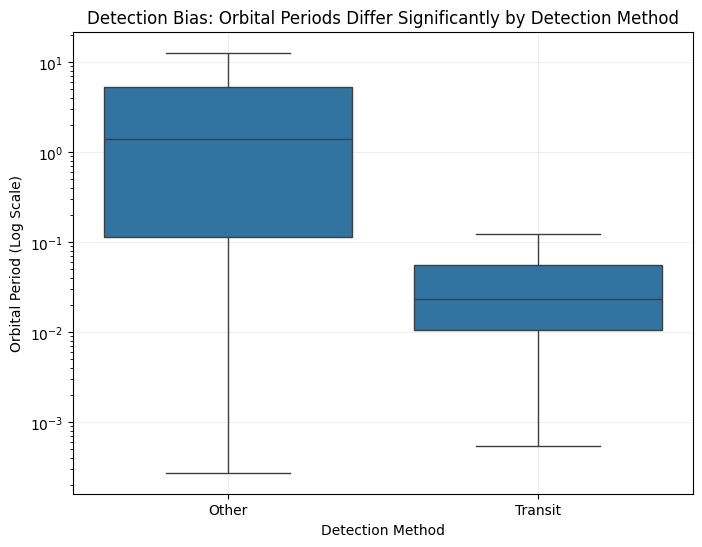

In [6]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x="method_group", y="orbital_period", showfliers=False)

plt.yscale("log")

plt.title("Detection Bias: Orbital Periods Differ Significantly by Detection Method")
plt.xlabel("Detection Method")
plt.ylabel("Orbital Period (Log Scale)")

plt.grid(alpha=0.2)

plt.show()

## Insight

Transit-detected planets show significantly shorter orbital periods compared to other methods, suggesting a strong observational bias toward close-in planets.

## Distribution Analysis: Transit vs. Other Methods

This histogram overlays orbital period distributions for transit and non-transit detections to further examine differences in detection patterns.

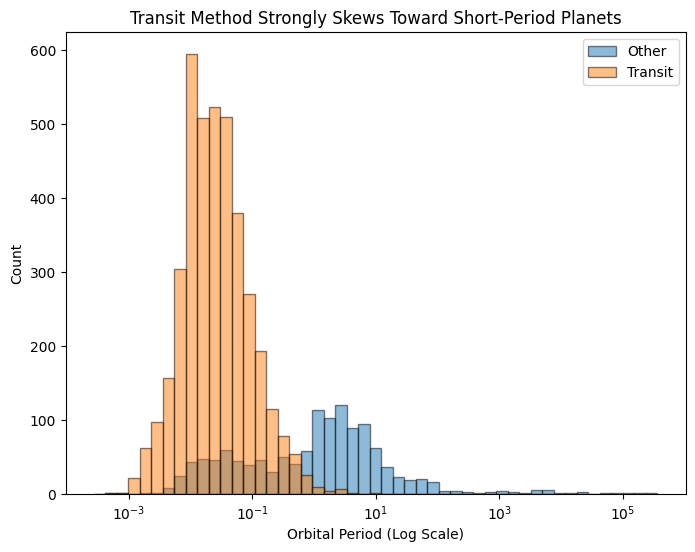

In [7]:
plt.figure(figsize=(8,6))

bins = np.logspace(
    np.log10(df["orbital_period"].min()),
    np.log10(df["orbital_period"].max()),
    50
)

for label, subset in df.groupby("method_group"):
    plt.hist(subset["orbital_period"], bins=bins, alpha=0.5, label=label, edgecolor='black')

plt.xscale("log")
plt.legend()

plt.title("Transit Method Strongly Skews Toward Short-Period Planets")
plt.xlabel("Orbital Period (Log Scale)")
plt.ylabel("Count")

plt.show()

## Insight

The distribution is heavily skewed toward short-period planets for the transit method, reinforcing the bias toward detecting close-in planets.

## Detection Method Share

This chart shows the proportion of exoplanets discovered by each detection method.

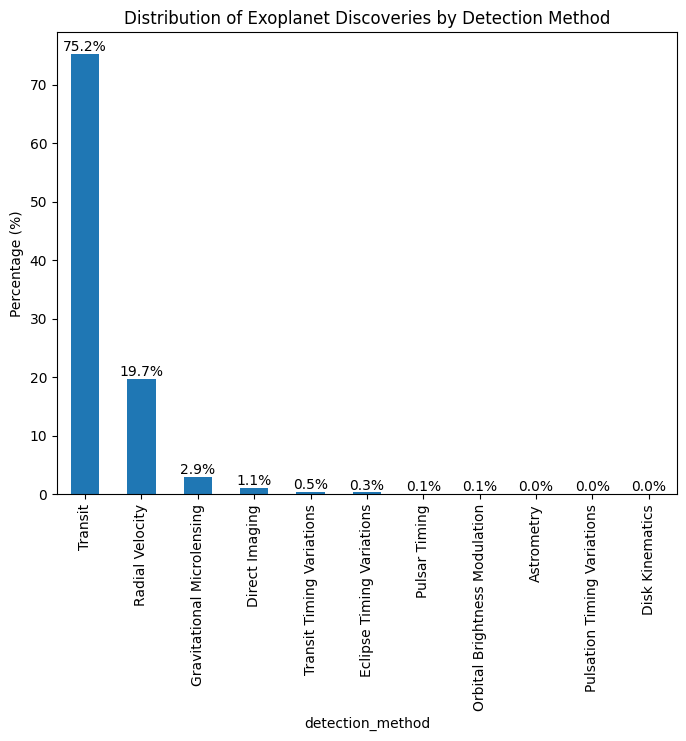

In [8]:
counts = df["detection_method"].value_counts(normalize=True) * 100
counts = counts.sort_values(ascending=False)

plt.figure(figsize=(8,6))
ax = counts.plot(kind="bar")

plt.ylabel("Percentage (%)")
plt.title("Distribution of Exoplanet Discoveries by Detection Method")

for i, v in enumerate(counts):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.show()

## Insight

The transit method accounts for the majority of discoveries (~75%), indicating dominance driven by detection efficiency rather than true planetary abundance.

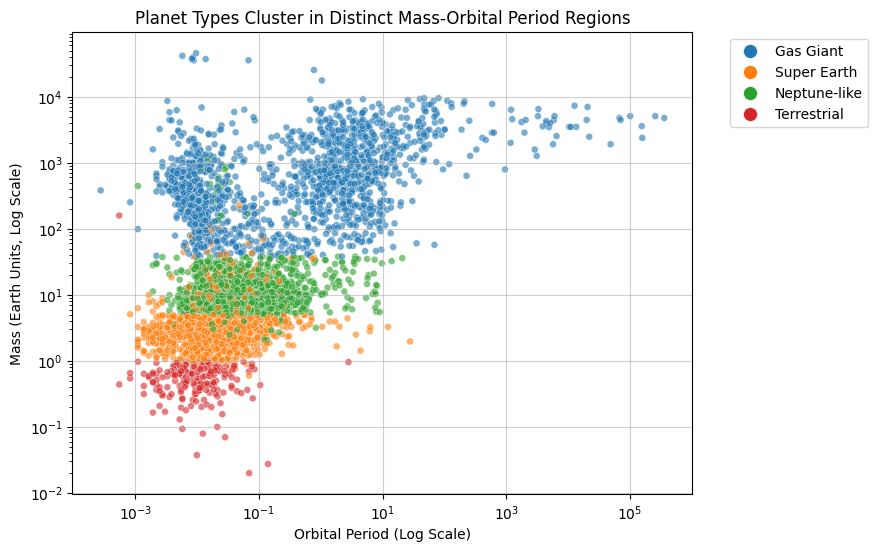

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df, #
    x="orbital_period",
    y="mass_earth",
    hue="planet_type",
    alpha=0.6,
    s=25
)

plt.xscale("log")
plt.yscale("log")

plt.title("Planet Types Cluster in Distinct Mass-Orbital Period Regions")
plt.xlabel("Orbital Period (Log Scale)")
plt.ylabel("Mass (Earth Units, Log Scale)")

plt.grid(alpha=0.6)

handles, labels = plt.gca().get_legend_handles_labels()

legend = plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    markerscale=2,
    frameon=True
)

for lh in legend.legend_handles:
    lh.set_alpha(1)

plt.show()

            log_mass  log_period
log_mass    1.000000    0.542451
log_period  0.542451    1.000000


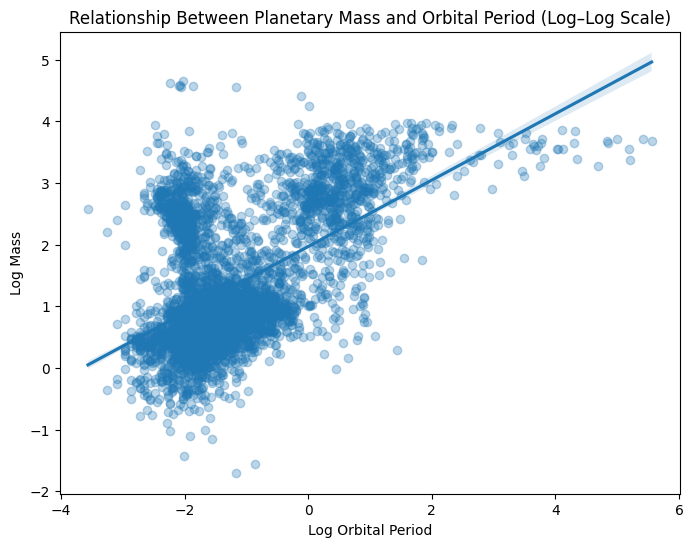

In [10]:
df["log_period"] = np.log10(df["orbital_period"])
df["log_mass"] = np.log10(df["mass_earth"])

corr = df[["log_mass", "log_period"]].corr()
print(corr)

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="log_period",
    y="log_mass",
    scatter_kws={"alpha":0.3}
)

plt.title("Relationship Between Planetary Mass and Orbital Period (Log–Log Scale)")
plt.xlabel("Log Orbital Period")
plt.ylabel("Log Mass")

plt.show()

## Statistical Validation and Relationship Analysis

A statistical test is used to determine whether the difference in orbital period distributions between detection methods is significant. Additionally, the relationship between planetary mass and orbital period is examined.

## Insight

The Mann-Whitney U test returns a p-value ≪ 0.05, confirming that orbital periods differ across detection methods.

There is only a weak correlation between planetary mass and orbital period, suggesting that detection bias is not driven by mass alone.

## Discovery Trends Over Time

This section examines how exoplanet discoveries have evolved over time.

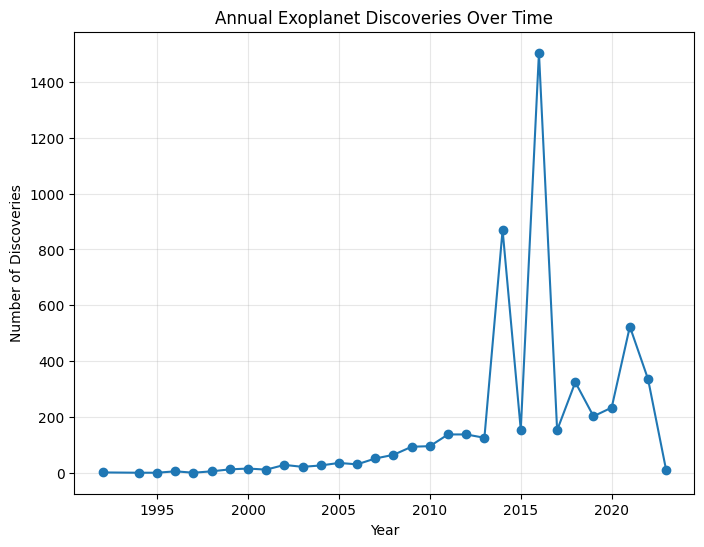

In [11]:
discoveries = df["discovery_year"].value_counts().sort_index()

plt.figure(figsize=(8,6))
discoveries.plot(marker='o')

plt.title("Annual Exoplanet Discoveries Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Discoveries")

plt.grid(alpha=0.3)

plt.show()

## Insight

Exoplanet discoveries accelerate significantly after 2010, reflecting improvements in detection technology and large-scale surveys.

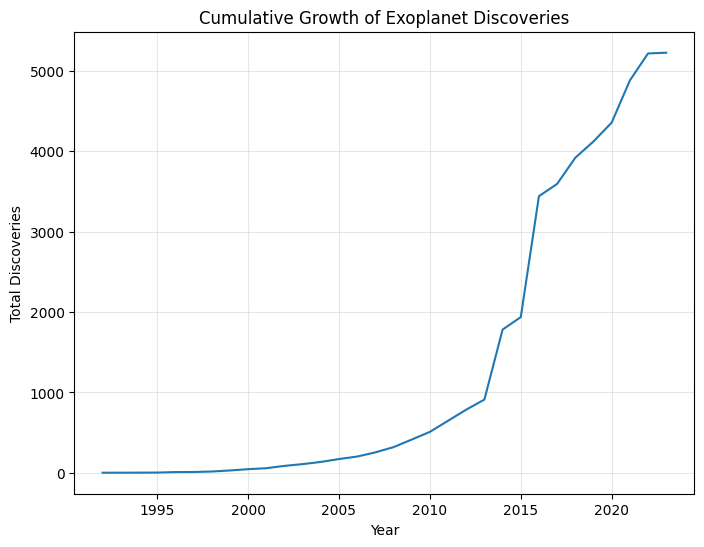

In [12]:
cumulative = discoveries.cumsum()

plt.figure(figsize=(8,6))
cumulative.plot()

plt.title("Cumulative Growth of Exoplanet Discoveries")
plt.xlabel("Year")
plt.ylabel("Total Discoveries")

plt.grid(alpha=0.3)

plt.show()

## Insight

The cumulative growth in discoveries is rapid, highlighting the increasing efficiency of detection methods over time.

<Figure size 800x600 with 0 Axes>

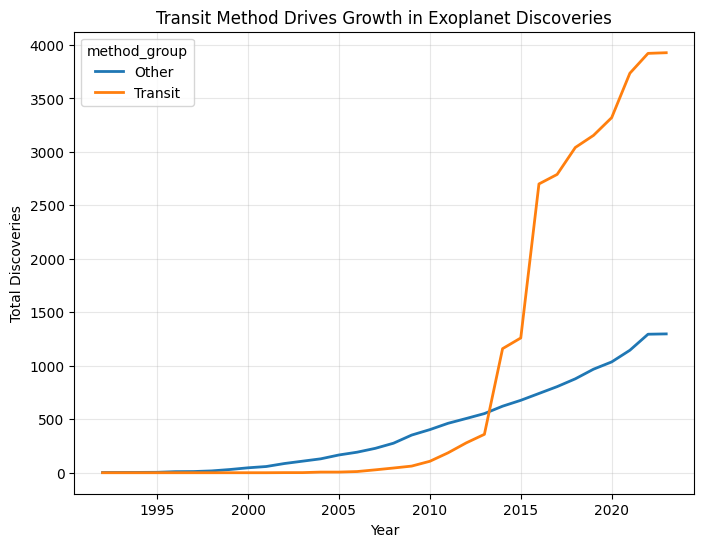

In [13]:
method_year = df.groupby(["discovery_year", "method_group"]).size().unstack().fillna(0)

plt.figure(figsize=(8,6))
method_year.cumsum().plot(figsize=(8,6), linewidth=2)

plt.title("Transit Method Drives Growth in Exoplanet Discoveries")
plt.xlabel("Year")
plt.ylabel("Total Discoveries")

plt.grid(alpha=0.3)

plt.show()

## Insight

The transit method becomes dominant after 2010, coinciding with large-scale survey missions capable of monitoring thousands of stars simultaneously.

In [14]:
transit = df[df["method_group"] == "Transit"]["orbital_period"]
other = df[df["method_group"] == "Other"]["orbital_period"]

stat, p = mannwhitneyu(transit, other)

print(f"P-value: {p:.3e}")

P-value: 0.000e+00


## Final Conclusion

The dominance of the transit method reflects scalability rather than planetary prevalence. Its ability to monitor thousands of stars simultaneously introduces a systematic bias toward short-period planets.

As a result, current exoplanet catalogues are not fully representative of the true planetary population, but instead reflect the limitations and efficiencies of detection techniques.